## Fine tuning flan-t5-base model using LoRA technique for dialogue summarization dataset

In this notebook, we will fine-tune an existing LLM from Hugging Face for enhanced dialogue summarization. we will use the [FLAN-T5](https://huggingface.co/docs/transformers/model_doc/flan-t5) model, which provides a high quality instruction tuned model and can summarize text out of the box. To improve the inferences, you will explore a full fine-tuning approach and evaluate the results with ROUGE metrics. Then you will perform Parameter Efficient Fine-Tuning (PEFT), evaluate the resulting model and see that the benefits of PEFT outweigh the slightly-lower performance metrics.

### Loading libraries

In [1]:
from datasets import load_dataset
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, GenerationConfig, TrainingArguments, Trainer
import torch
import time
import evaluate
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt



/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



### Load Dataset and LLM

You are going to continue experimenting with the [DialogSum](https://huggingface.co/datasets/knkarthick/dialogsum) Hugging Face dataset. It contains 10,000+ dialogues with the corresponding manually labeled summaries and topics. 

In [2]:
huggingface_dataset_name = "knkarthick/dialogsum"

dataset = load_dataset(huggingface_dataset_name)

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 500
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1500
    })
})

### Loading the model

In [3]:
model_name='google/flan-t5-base'

original_model = AutoModelForSeq2SeqLM.from_pretrained(model_name, torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_name)

### Function to calculate the number of model's parameter

In [4]:
def model_parameters(model):
    trainable_model_params = 0
    all_model_params = 0
    for _, param in model.named_parameters():
        all_model_params += param.numel()
        if param.requires_grad:
            trainable_model_params += param.numel()
    return f"trainable model parameters: {trainable_model_params}"

print(model_parameters(original_model))

trainable model parameters: 247577856


It is possible to pull out the number of model parameters and find out how many of them are trainable. The following function can be used to do that, at this stage, you do not need to go into details of it. 

### Test the Model before fine-tuning


In [5]:
index = 200

dialogue = dataset['test'][index]['dialogue']
summary = dataset['test'][index]['summary']

prompt = f"""
Summarize the following conversation.

{dialogue}

Summary:
"""

inputs = tokenizer(prompt, return_tensors='pt')
output = tokenizer.decode(
    original_model.generate(
        inputs["input_ids"], 
        max_new_tokens=200,
    )[0], 
    skip_special_tokens=True
)

print(f'Input prompt:{prompt}')
print(f'\n\n Human summary: \n{summary}\n')
print(f'\n\nOriginal model summarization before fine-tuning: \n\n{output}')

Input prompt:
Summarize the following conversation.

#Person1#: Have you considered upgrading your system?
#Person2#: Yes, but I'm not sure what exactly I would need.
#Person1#: You could consider adding a painting program to your software. It would allow you to make up your own flyers and banners for advertising.
#Person2#: That would be a definite bonus.
#Person1#: You might also want to upgrade your hardware because it is pretty outdated now.
#Person2#: How can we do that?
#Person1#: You'd probably need a faster processor, to begin with. And you also need a more powerful hard disc, more memory and a faster modem. Do you have a CD-ROM drive?
#Person2#: No.
#Person1#: Then you might want to add a CD-ROM drive too, because most new software programs are coming out on Cds.
#Person2#: That sounds great. Thanks.

Summary:



 Human summary: 
#Person1# teaches #Person2# how to upgrade software and hardware in #Person2#'s system.



Original model summarization before fine-tuning: 

#Person

### Defining the best value for dialogue and summary tokenization max_length parameter

Model max length for Flan-T5 Large: 512


Map: 100%|███████████████████████| 12460/12460 [00:05<00:00, 2312.18 examples/s]



Prompt (Dialogue + Start/End) Lengths:
Max: 1579, Min: 66
Mean: 234.40, Median: 212.0
95th Percentile: 426.00
99th Percentile: 624.41

Summary Lengths:
Max: 277, Min: 9
Mean: 41.27, Median: 38.0
95th Percentile: 73.00
99th Percentile: 96.00


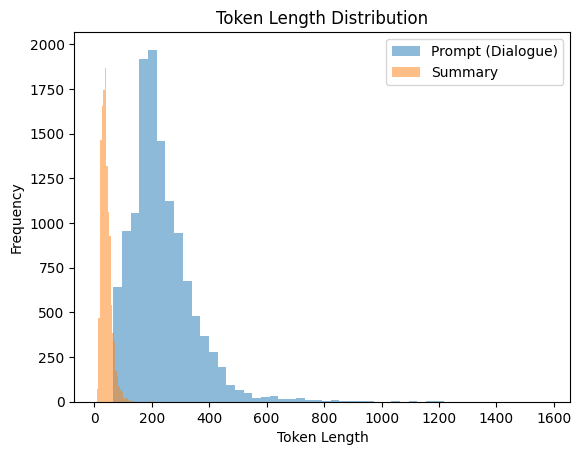

In [11]:
print(f"Model max length for Flan-T5 Large: {tokenizer.model_max_length}")  

# Function to compute token lengths without padding/truncation
def get_token_lengths(example):
    start_prompt = 'Summarize the following conversation.\n\n'
    end_prompt = '\n\nSummary: '
    # Construct prompt as in your tokenize_function
    prompt = start_prompt + example["dialogue"] + end_prompt
    dialogue_tokens = tokenizer(prompt, truncation=False, padding=False).input_ids
    summary_tokens = tokenizer(example["summary"], truncation=False, padding=False).input_ids
    return {
        "prompt_length": len(dialogue_tokens),  # Length of prompt (dialogue + start/end)
        "summary_length": len(summary_tokens)   # Length of summary
    }

# Apply to the 'train' split (or combine splits if needed)
lengths_dataset = dataset["train"].map(get_token_lengths, batched=False)

# Collect lengths
prompt_lengths = lengths_dataset["prompt_length"]
summary_lengths = lengths_dataset["summary_length"]

# Compute statistics
def print_stats(lengths, name):
    print(f"\n{name} Lengths:")
    print(f"Max: {max(lengths)}, Min: {min(lengths)}")
    print(f"Mean: {np.mean(lengths):.2f}, Median: {np.median(lengths)}")
    print(f"95th Percentile: {np.percentile(lengths, 95):.2f}")
    print(f"99th Percentile: {np.percentile(lengths, 99):.2f}")

print_stats(prompt_lengths, "Prompt (Dialogue + Start/End)")
print_stats(summary_lengths, "Summary")

# Visualize distributions
plt.hist(prompt_lengths, bins=50, alpha=0.5, label="Prompt (Dialogue)")
plt.hist(summary_lengths, bins=50, alpha=0.5, label="Summary")
plt.xlabel("Token Length")
plt.ylabel("Frequency")
plt.legend()
plt.title("Token Length Distribution")
plt.show()

### The 95th percentile is chosen as a practical cutoff to cover 95% of the data, minimizing truncation while avoiding excessive padding for outliers

In [7]:
# Suggest optimal max_length values
max_prompt_length = min(int(np.percentile(prompt_lengths, 95)), tokenizer.model_max_length)
max_summary_length = min(int(np.percentile(summary_lengths, 95)), tokenizer.model_max_length)
print(f"\nSuggested max_length for prompts (input_ids): {max_prompt_length}")
print(f"Suggested max_length for summaries (labels): {max_summary_length}")


Suggested max_length for prompts (input_ids): 426
Suggested max_length for summaries (labels): 73


In [10]:
# tokenize_function 
def tokenize_function(example):
    start_prompt = 'Summarize the following conversation.\n\n'
    end_prompt = '\n\nSummary: '
    prompt = [start_prompt + dialogue + end_prompt for dialogue in example["dialogue"]]
    example['input_ids'] = tokenizer(
        prompt, 
        padding="max_length", 
        truncation=True, 
        max_length=max_prompt_length,  # Use calculated value
        return_tensors="pt"
    ).input_ids
    example['labels'] = tokenizer(
        example["summary"], 
        padding="max_length", 
        truncation=True, 
        max_length=max_summary_length,  # Use calculated value
        return_tensors="pt"
    ).input_ids
    return example

# Tokenize the dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(['id', 'topic', 'dialogue', 'summary'])

Map: 100%|███████████████████████| 12460/12460 [00:02<00:00, 5111.77 examples/s]


In [9]:
print(tokenized_datasets)
print(tokenized_datasets['train'][0])


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 500
    })
    test: Dataset({
        features: ['input_ids', 'labels'],
        num_rows: 1500
    })
})
{'input_ids': [12198, 1635, 1737, 8, 826, 3634, 5, 1713, 345, 13515, 536, 4663, 10, 2018, 6, 1363, 5, 3931, 5, 27, 31, 51, 7582, 12833, 77, 7, 5, 1615, 33, 25, 270, 469, 58, 1713, 345, 13515, 357, 4663, 10, 27, 435, 34, 133, 36, 3, 9, 207, 800, 12, 129, 3, 9, 691, 18, 413, 5, 1713, 345, 13515, 536, 4663, 10, 2163, 6, 168, 6, 25, 43, 29, 31, 17, 141, 80, 21, 305, 203, 5, 148, 225, 43, 80, 334, 215, 5, 1713, 345, 13515, 357, 4663, 10, 27, 214, 5, 27, 2320, 38, 307, 38, 132, 19, 1327, 1786, 6, 572, 281, 217, 8, 2472, 58, 1713, 345, 13515, 536, 4663, 10, 1548, 6, 8, 200, 194, 12, 1792, 2261, 21154, 19, 12, 253, 91, 81, 135, 778, 5, 264, 653, 12, 369, 44, 709, 728, 3, 9, 215, 21, 39, 293, 207,


## Perform Parameter Efficient Fine-Tuning (PEFT)

Now, let's perform **Parameter Efficient Fine-Tuning (PEFT)** fine-tuning as opposed to "full fine-tuning" as you did above. PEFT is a form of instruction fine-tuning that is much more efficient than full fine-tuning - with comparable evaluation results as you will see soon. 

PEFT is a generic term that includes **Low-Rank Adaptation (LoRA)** and prompt tuning (which is NOT THE SAME as prompt engineering!). In most cases, when someone says PEFT, they typically mean LoRA. LoRA, at a very high level, allows the user to fine-tune their model using fewer compute resources (in some cases, a single GPU). After fine-tuning for a specific task, use case, or tenant with LoRA, the result is that the original LLM remains unchanged and a newly-trained “LoRA adapter” emerges. This LoRA adapter is much, much smaller than the original LLM - on the order of a single-digit % of the original LLM size (MBs vs GBs).  

That said, at inference time, the LoRA adapter needs to be reunited and combined with its original LLM to serve the inference request.  The benefit, however, is that many LoRA adapters can re-use the original LLM which reduces overall memory requirements when serving multiple tasks and use cases.


###  Setup the PEFT/LoRA model for Fine-Tuning

You need to set up the PEFT/LoRA model for fine-tuning with a new layer/parameter adapter. Using PEFT/LoRA, you are freezing the underlying LLM and only training the adapter. Have a look at the LoRA configuration below. Note the rank (`r`) hyper-parameter, which defines the rank/dimension of the adapter to be trained.

In [8]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=64, # Rank
    lora_alpha=64,
    target_modules=["q", "v"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM # FLAN-T5
)

Add LoRA adapter layers/parameters to the original LLM to be trained.

In [9]:
peft_model = get_peft_model(original_model, 
                            lora_config)
print(model_parameters(peft_model))

trainable model parameters: 7077888


<a name='3.2'></a>
### 3.2 - Train PEFT Adapter

Define training arguments and create `Trainer` instance.

In [10]:
output_dir = "Fine_tuning_FlanT5_base_model_LoRA_summerization"


peft_training_args = TrainingArguments(
    output_dir=f'{output_dir}/model',
    logging_dir=f'{output_dir}/logs',

    auto_find_batch_size=True,
    learning_rate=1e-4, # Higher learning rate than full fine-tuning.
    lr_scheduler_type="cosine",    
    num_train_epochs=40,
    warmup_steps=200,
    #label_smoothing_factor=0.1,
    weight_decay=0.01,
    #logging_steps=1,
    #max_steps=1,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    optim="paged_adamw_8bit",


    # Evaluation & Logging
    evaluation_strategy="steps",
    eval_steps=500,  
    save_steps=500,
    logging_strategy="steps",
    logging_steps=10,  
    save_total_limit=2,
)
    
peft_trainer = Trainer(
    model=peft_model,
    args=peft_training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"]
)

/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [11]:
peft_trainer.train()

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.
/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss
500,0.278500,0.193525
1000,0.219200,0.164104
1500,0.200500,0.156731
2000,0.187000,0.152055
2500,0.179100,0.148745
3000,0.184500,0.147650
3500,0.175300,0.145925
4000,0.159300,0.142517
4500,0.166800,0.142036
5000,0.165000,0.141325


/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/utsajinlab/anaconda3/envs/fine_tuning/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return

TrainOutput(global_step=15560, training_loss=0.4261309979200976, metrics={'train_runtime': 64862.4313, 'train_samples_per_second': 7.684, 'train_steps_per_second': 0.24, 'total_flos': 1.404918881625047e+18, 'train_loss': 0.4261309979200976, 'epoch': 39.89887640449438})

In [12]:
# Save the model
save_dir = f'{output_dir}/final'

peft_trainer.save_model(save_dir)

tokenizer.save_pretrained(save_dir)

print(f"Final model saved to: {save_dir}")

Final model saved to: Fine_tuning_FlanT5_base_model_LoRA_summerization/final


In [13]:
# peft_trainer.train()

# peft_model_path="./peft-dialogue-summary-checkpoint-local"

# peft_trainer.model.save_pretrained(peft_model_path)
# tokenizer.save_pretrained(peft_model_path)

Prepare this model by adding an adapter to the original FLAN-T5 model. You are setting `is_trainable=False` because the plan is only to perform inference with this PEFT model. If you were preparing the model for further training, you would set `is_trainable=True`.

In [14]:

model_name='google/flan-t5-base'

original_model = AutoModelForSeq2SeqLM.from_pretrained(model_name, torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_name)


In [15]:
from peft import PeftModel, PeftConfig
save_dir = f'{output_dir}/final'

peft_model_base = AutoModelForSeq2SeqLM.from_pretrained(model_name, torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_name)

#instruct_model = AutoModelForSeq2SeqLM.from_pretrained(save_dir, local_files_only=True)
peft_model = PeftModel.from_pretrained(peft_model_base, 
                                       save_dir, 
                                       torch_dtype=torch.bfloat16,
                                       is_trainable=False)
peft_model = peft_model.merge_and_unload()


In [16]:
# Check if LoRA adapters are applied
print(f"Active adapters: {peft_model.active_adapters}")


Active adapters: <bound method PeftAdapterMixin.active_adapters of T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(

<a name='3.3'></a>
### 3.3 - Evaluate the Model Qualitatively (Human Evaluation)

Make inferences for the same example as in sections [1.3](#1.3) and [2.3](#2.3), with the original model, fully fine-tuned and PEFT model.

In [17]:
def inference(text, model, tokenizer, max_input_tokens=2048, max_output_tokens=200):
    # Tokenize input
    input_ids = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_input_tokens
    )["input_ids"].to(model.device)

    # Generate response
    with torch.no_grad():
        generated_tokens = model.generate(
            input_ids=input_ids,
            max_length=max_output_tokens,  
            pad_token_id=tokenizer.eos_token_id  
        )

    # Decode and strip input prompt
    generated_text = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]
    

    return generated_text


In [18]:
index = 1
dialogue = dataset['test'][index]['dialogue']
human_baseline_summary = dataset['test'][index]['summary']

prompt = f"""
Summarize the following conversation.

{dialogue}

Summary:
"""


original_model_text_output = inference(dialogue,original_model, tokenizer )
peft_model_text_output = inference(dialogue,peft_model, tokenizer )

print(f'BASELINE HUMAN SUMMARY:\n{human_baseline_summary}')
print(f'ORIGINAL MODEL:\n{original_model_text_output}')
print(f'PEFT MODEL:\n{peft_model_text_output}')

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


BASELINE HUMAN SUMMARY:
In order to prevent employees from wasting time on Instant Message programs, #Person1# decides to terminate the use of those programs and asks Ms. Dawson to send out a memo to all employees by the afternoon.
ORIGINAL MODEL:
#Person1#: Ms. Dawson, I need you to take a dictation for me.
PEFT MODEL:
Ms. Dawson takes a dictation from the office to tell all employees that all office communications are restricted to email correspondence and official memos. Ms. Dawson also tells employees that Instant Messaging is strictly prohibited and employees will have to change their communication methods. Ms. Dawson also tells employees that if they continue to use Instant Messaging, they will be placed on probation and will face termination.



### Evaluate the Model Quantitatively (with ROUGE Metric)

The [ROUGE metric](https://en.wikipedia.org/wiki/ROUGE_(metric)) helps quantify the validity of summarizations produced by models. It compares summarizations to a "baseline" summary which is usually created by a human. While not perfect, it does indicate the overall increase in summarization effectiveness that we have accomplished by fine-tuning.

In [19]:
rouge = evaluate.load('rouge')

Generate the outputs for the sample of the test dataset (only 10 dialogues and summaries to save time), and save the results.

In [21]:
dialogues = dataset['test'][1100:1200]['dialogue']
human_baseline_summaries = dataset['test'][1100:1200]['summary']

original_model_summaries = []
peft_model_summaries = []

for idx, dialogue in enumerate(dialogues):
    prompt = f"""
Summarize the following conversation.

{dialogue}

Summary: """
    
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids

    human_baseline_text_output = human_baseline_summaries[idx]
    
    original_model_outputs = original_model.generate(input_ids=input_ids, generation_config=GenerationConfig(max_new_tokens=200))
    original_model_text_output = tokenizer.decode(original_model_outputs[0], skip_special_tokens=True)

    peft_model_outputs = peft_model.generate(input_ids=input_ids, generation_config=GenerationConfig(max_new_tokens=200))
    peft_model_text_output = tokenizer.decode(peft_model_outputs[0], skip_special_tokens=True)

    original_model_summaries.append(original_model_text_output)
    peft_model_summaries.append(peft_model_text_output)

zipped_summaries = list(zip(human_baseline_summaries, original_model_summaries, peft_model_summaries))
 
df = pd.DataFrame(zipped_summaries, columns = ['human_baseline_summaries', 'original_model_summaries', 'peft_model_summaries'])
df

Token indices sequence length is longer than the specified maximum sequence length for this model (559 > 512). Running this sequence through the model will result in indexing errors


,human_baseline_summaries,original_model_summaries,peft_model_summaries
0,#Person2# asks #Person1# about a new service a...,"#Person1#: Hello, Sir. How can I help you?",#Person2# asks #Person1# about a new service w...
1,#Person1# would like to store his luggage in #...,#Person1#: I'm checking out in 30 minutes. #Pe...,#Person1# is checking out in 30 minutes and as...
2,"#Person1# wants to hit some place, but he hesi...",#Person1#: I'm checking out in 30 minutes. #Pe...,#Person1# is checking out in 30 minutes and as...
3,#Person1# wants to hit some place. So he needs...,#Person1#: I'm checking out in 30 minutes. #Pe...,#Person1# is checking out in 30 minutes and as...
4,#Person1# wants to know the charge at #Person2...,The buffet is a buffet.,#Person1# tells #Person2# the buffet charge is...
...,...,...,...
95,#Person2# asks his daughter about admission re...,The father asked about the admission requireme...,#Person1#'s dad is considering quitting his jo...
96,#Person2# wants to know admission requirement ...,The father asked about the admission requireme...,#Person1#'s dad is considering quitting his jo...
97,Kalina calls Professor Clark that she needs to...,#Person1: I ran my car into a tree yesterday a...,Kalina runs her car into a tree yesterday and ...
98,Kalina calls Professor Clark and asks for leav...,#Person1: I ran my car into a tree yesterday a...,Kalina runs her car into a tree yesterday and ...


In [40]:
df.iloc[3,1]

'The traffic jam at the Carrefour intersection is a problem.'

#### Compute ROUGE score for this subset of the data. 

In [23]:
rouge = evaluate.load('rouge')

original_model_results = rouge.compute(
    predictions=original_model_summaries,
    references=human_baseline_summaries[0:len(original_model_summaries)],
    use_aggregator=True,
    use_stemmer=True,
)

peft_model_results = rouge.compute(
    predictions=peft_model_summaries,
    references=human_baseline_summaries[0:len(peft_model_summaries)],
    use_aggregator=True,
    use_stemmer=True,
)

print('ORIGINAL MODEL:')
print(original_model_results)

print('PEFT MODEL:')
print(peft_model_results)

ORIGINAL MODEL:
{'rouge1': np.float64(0.21582562416306209), 'rouge2': np.float64(0.04898615769875031), 'rougeL': np.float64(0.17610512297362702), 'rougeLsum': np.float64(0.17594572082265672)}
PEFT MODEL:
{'rouge1': np.float64(0.37485875436782023), 'rouge2': np.float64(0.127543819110653), 'rougeL': np.float64(0.2812361080799688), 'rougeLsum': np.float64(0.28180612725190646)}
